# Exercício do Lab03

In [6]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset = fetch_ucirepo("Breast Cancer")

### Visualização inicial do que são os dados

In [23]:
X, y = dataset.data.features, dataset.data.targets

# Verificando os primeiros 5 registros do dataset
X.head(5)

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [22]:
# Verificando distribuição das classes
y.value_counts()

Class               
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64

In [24]:
# Verificando dados nulos
X.isnull().sum()

age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiat       0
dtype: int64

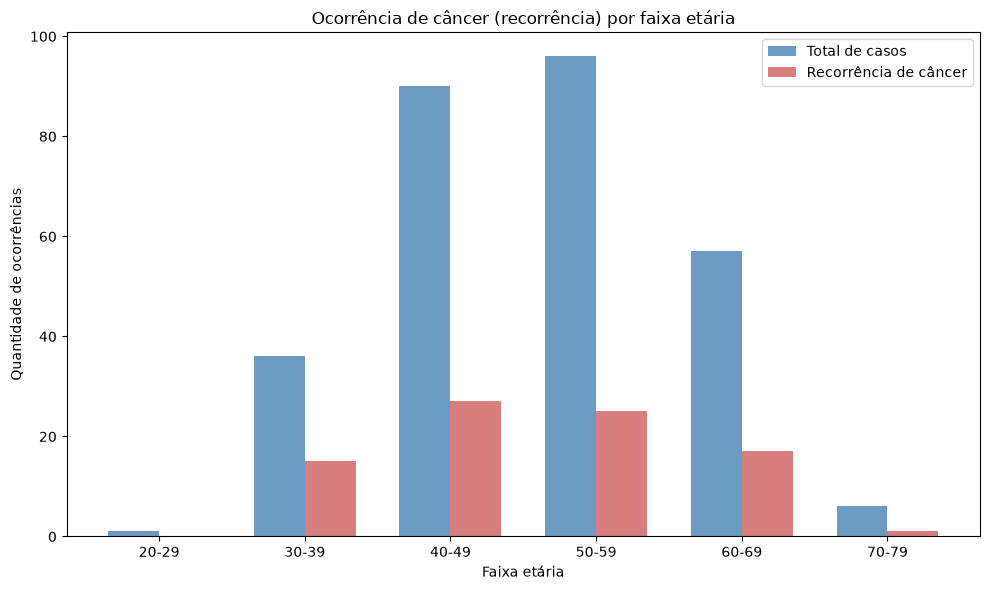

In [ ]:
df = X.copy()
df['Class'] = y['Class']

age_order = sorted(df['age'].unique(), key=lambda a: int(a.split('-')[0]))

total_counts = df['age'].value_counts().reindex(age_order, fill_value=0)
recurrence_counts = (
    df[df['Class'] == 'recurrence-events']['age']
    .value_counts()
    .reindex(age_order, fill_value=0)
)

x = np.arange(len(age_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, total_counts.values, width, label='Total de casos', color='steelblue', alpha=0.8)
ax.bar(x + width / 2, recurrence_counts.values, width, label='Recorrência de câncer', color='indianred', alpha=0.8)

ax.set_xlabel('Faixa etária')
ax.set_ylabel('Quantidade de ocorrências')
ax.set_title('Reocorrência de câncer por faixa etária')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
# Verificando se paciente tratado com radiação tem maior chance de recorrência de câncer
irradiation = [1 if val == 'yes' else 0 for val in df['irradiat']]
total = sum(irradiation)
print(f"Pacientes tratados com radiação são recorrentes em {total/len(irradiation)*100:.2f}% dos casos.")

Pacientes tratados com radiação são recorrentes em 23.78% dos casos.
